In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import sys
sys.path.append('../../utils')
from functions import * 

In [3]:
# Metadata file:
metadata_file = '/gpfs/commons/groups/knowles_lab/data/tabula_muris/smart_seq/d8a0c006-2991-5ddb-8ed8-7b7e8c187fe3/all_tabula_muris_samples_w_celltype_column.txt'
metadata = pd.read_csv(metadata_file, sep='\t', index_col=0)
print("Loaded metadata file!")
print_separator()

organ = 'Brain'

# Subset the metadata file to only include the organ of interest:
metadata = metadata[metadata['tissue'].str.contains(organ)]
print("The number of cells in the metadata corresponding to the organ of interest is: " + str(len(metadata.index)))
print_separator()

Loaded metadata file!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The number of cells in the metadata corresponding to the organ of interest is: 7856
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [4]:
metadata["cell_id"] = metadata.index

In [5]:
# keep cell_type as everything after "Myeloid_"
metadata.cell_type = metadata.cell_type.str.split("Myeloid_").str[1]
metadata.cell_type.unique() 

array(['astrocyte', 'oligodendrocyte', 'endothelial_cell', 'neuron',
       'oligodendrocyte_precursor_cell', 'Bergmann_glial_cell',
       'brain_pericyte', 'microglial_cell', 'macrophage'], dtype=object)

In [6]:
# load PCA and UMAP representations of brain data using gene counts 
PCA_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_pca_embedding.csv')
UMAP_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_umap_embedding.csv')

#Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')
Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')
# junction 548/549 data 
psap_juncs = pd.read_csv('/gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/Leaflet/simple_data_junc_548_549.csv')
# Read in file with normalized Psap gene expession 
psap_exp = pd.read_csv('/gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/data_processing/psap_expression.csv')

In [7]:
psap_exp.head()

,cell_id,psap_expression
0,A12-MAA000926-3_9_M-1-1,3.596540
1,A16-MAA000564-3_10_M-1-1,3.303160
2,A20-MAA000550-3_10_M-1-1,3.437400
3,A20-MAA000947-3_9_M-1-1,3.285292
4,A3-MAA000560-3_10_M-1-1,2.706468


In [52]:
psap_juncs

,cell_id_index,548_junc_ratio,549_junc_ratio,cell_id
0,0,0.022222,0.977778,A14-MAA000581-3_10_M-1-1
1,1,0.030000,0.970000,A14-MAA000930-3_8_M-1-1
2,2,0.375000,0.625000,A14-MAA000947-3_9_M-1-1
3,3,0.009091,0.990909,A15-MAA000561-3_10_M-1-1
4,4,0.010590,0.989410,A19-MAA000581-3_10_M-1-1
...,...,...,...,...
7393,7594,0.000000,1.000000,H22-MAA000944-3_9_M-1-1
7394,7624,0.000000,1.000000,J16-MAA000925-3_9_M-1-1
7395,7777,0.000000,1.000000,O4-B000404-3_56_F-1-1
7396,7781,0.000000,1.000000,O7-B001688-3_38_F-1-1


In [8]:
# remove unnamed:0 column from psap_juncs 
psap_juncs = psap_juncs.drop(columns=['Unnamed: 0'])
psap_juncs.drop(columns=['cell_type'], inplace=True)
psap_juncs['cell_id'] = [x.split('_B')[0] for x in psap_juncs['cell_id']]
psap_juncs.head()

,cell_id_index,548_junc_ratio,549_junc_ratio,cell_id
0,0,0.022222,0.977778,A14-MAA000581-3_10_M-1-1
1,1,0.030000,0.970000,A14-MAA000930-3_8_M-1-1
2,2,0.375000,0.625000,A14-MAA000947-3_9_M-1-1
3,3,0.009091,0.990909,A15-MAA000561-3_10_M-1-1
4,4,0.010590,0.989410,A19-MAA000581-3_10_M-1-1


In [9]:
UMAP_rep.drop(columns=['Unnamed: 0'], inplace=True)
UMAP_rep.drop(columns = ['cell_type'], inplace=True)
UMAP_rep.head()
# rename UMAP_0 and UMAP_1 to UMAP_1 and UMAP_2
UMAP_rep.rename(columns={'UMAP_0':'UMAP_1', 'UMAP_1':'UMAP_2'}, inplace=True)

In [10]:
Leaflet_rep.drop(columns=['Unnamed: 0'], inplace=True)
Leaflet_rep.drop(columns=['cell_type'], inplace=True)
Leaflet_rep['cell_id'] = [x.split('_B')[0] for x in Leaflet_rep['cell_id']]
Leaflet_rep.head()

,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,cell_id
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A14-MAA000581-3_10_M-1-1
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A14-MAA000930-3_8_M-1-1
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A14-MAA000947-3_9_M-1-1
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A15-MAA000561-3_10_M-1-1
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A19-MAA000581-3_10_M-1-1


In [11]:
UMAP_rep = UMAP_rep.merge(metadata, on=['cell_id'], how='left')

In [12]:
# combine UMAP and BB mixture results
UMAP_rep = UMAP_rep.merge(Leaflet_rep, on='cell_id', how='left')

# merge UMAP_rep with psap_juncs
UMAP_rep = UMAP_rep.merge(psap_juncs, on='cell_id', how='left')

# merge UMAP_rep with psap_exp
UMAP_rep = UMAP_rep.merge(psap_exp, on='cell_id', how='left')
UMAP_rep['leiden'] = 'leiden_' + UMAP_rep['leiden'].astype(str)

In [13]:
UMAP_rep.head()

,UMAP_1,UMAP_2,cell_id,leiden,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type,...,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,cell_id_index,548_junc_ratio,549_junc_ratio,psap_expression
0,4.151055,-10.884573,A12-MAA000926-3_9_M-1-1,leiden_10,oligodendrocyte precursor cell,NaN,3_9_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,...,0.0,0.0,0.0,0.0,0.0,0.0,161.0,0.594595,0.405405,3.596540
1,4.214687,-8.269217,A16-MAA000564-3_10_M-1-1,leiden_10,oligodendrocyte precursor cell,NaN,3_10_M,Striatum,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,...,0.0,0.0,0.0,0.0,0.0,0.0,162.0,0.524715,0.475285,3.303160
2,4.182742,-10.664248,A20-MAA000550-3_10_M-1-1,leiden_10,oligodendrocyte precursor cell,NaN,3_10_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,...,0.0,0.0,0.0,0.0,0.0,0.0,163.0,0.967427,0.032573,3.437400
3,3.834672,-10.274726,A20-MAA000947-3_9_M-1-1,leiden_10,oligodendrocyte precursor cell,NaN,3_9_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,...,0.0,0.0,0.0,0.0,0.0,0.0,164.0,0.277778,0.722222,3.285292
4,4.525207,-10.466123,A3-MAA000560-3_10_M-1-1,leiden_10,oligodendrocyte precursor cell,NaN,3_10_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,...,0.0,0.0,0.0,1.0,0.0,0.0,165.0,0.495327,0.504673,2.706468


In [14]:
UMAP_rep.cell_type.unique()

array(['oligodendrocyte_precursor_cell', 'macrophage', 'endothelial_cell',
       'oligodendrocyte', 'brain_pericyte', 'Bergmann_glial_cell',
       'neuron', 'astrocyte', 'microglial_cell'], dtype=object)

In [15]:
color_mapping = {
    'oligodendrocyte': (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
    'endothelial_cell': (1.0, 0.4980392156862745, 0.0),
    'microglial_cell': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
    'oligodendrocyte_precursor_cell': (0.9686274509803922, 0.5058823529411764, 0.7490196078431373),
    'neuron': (0.596078431372549, 0.3058823529411765, 0.6392156862745098),
    'brain_pericyte': (0.30196078431372547, 0.6862745098039216, 0.2901960784313726),
    'astrocyte': (1.0, 1.0, 0.2),
    'macrophage': (0.6509803921568628, 0.33725490196078434, 0.1568627450980392), 
    'Bergmann_glial_cell': (0.6, 0.6, 0.6)
}

print(color_mapping)
#color_mapping = dict(zip(unique_cell_types, palette))

{'oligodendrocyte': (0.21568627450980393, 0.49411764705882355, 0.7215686274509804), 'endothelial_cell': (1.0, 0.4980392156862745, 0.0), 'microglial_cell': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745), 'oligodendrocyte_precursor_cell': (0.9686274509803922, 0.5058823529411764, 0.7490196078431373), 'neuron': (0.596078431372549, 0.3058823529411765, 0.6392156862745098), 'brain_pericyte': (0.30196078431372547, 0.6862745098039216, 0.2901960784313726), 'astrocyte': (1.0, 1.0, 0.2), 'macrophage': (0.6509803921568628, 0.33725490196078434, 0.1568627450980392), 'Bergmann_glial_cell': (0.6, 0.6, 0.6)}


In [16]:
# Print color mapping for reference
for cell_type, color in color_mapping.items():
    print(f"{cell_type}: {color}")

oligodendrocyte: (0.21568627450980393, 0.49411764705882355, 0.7215686274509804)
endothelial_cell: (1.0, 0.4980392156862745, 0.0)
microglial_cell: (0.8941176470588236, 0.10196078431372549, 0.10980392156862745)
oligodendrocyte_precursor_cell: (0.9686274509803922, 0.5058823529411764, 0.7490196078431373)
neuron: (0.596078431372549, 0.3058823529411765, 0.6392156862745098)
brain_pericyte: (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)
astrocyte: (1.0, 1.0, 0.2)
macrophage: (0.6509803921568628, 0.33725490196078434, 0.1568627450980392)
Bergmann_glial_cell: (0.6, 0.6, 0.6)


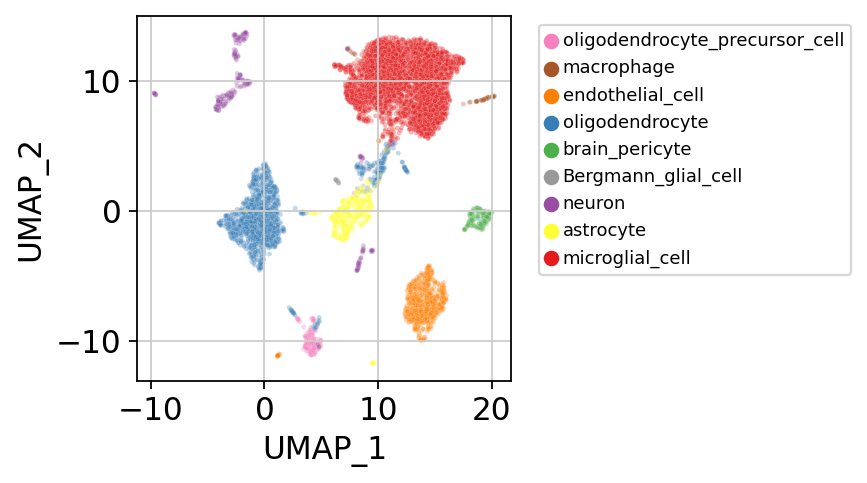

In [17]:
# 1. Define a color palette for 'cell_type'
unique_cell_types = UMAP_rep['cell_type'].unique()
#palette = sns.color_palette("Set1", n_colors = len(unique_cell_types))
#color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))
#color_mapping = dict(zip(unique_cell_types, palette))

# Plot
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['cell_type'], palette=color_mapping, alpha=0.3, s=5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

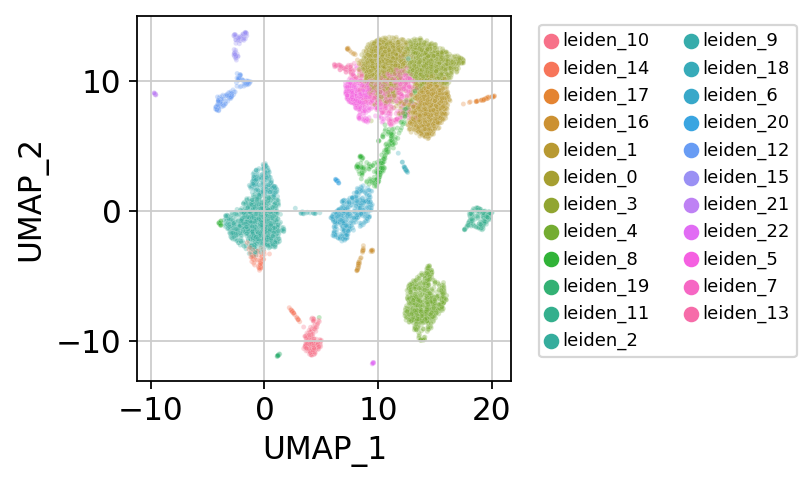

In [18]:
plt.figure(figsize=(3, 3))
# add "leid" to every value in the leiden column 
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['leiden'], alpha=0.3, s=5)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
# break up legend into two columns
# make UMAP_rep["leiden"] ordered in legend 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small', ncol=2)
plt.show()

In [19]:
# figure out which CellState has a value of 1 and assign that cell state number of the cell 
# find columns that have CellState in them?
cellstates = [col for col in UMAP_rep.columns if 'CellState' in col]
UMAP_rep["cellassignment"] = UMAP_rep[cellstates].idxmax(axis=1)

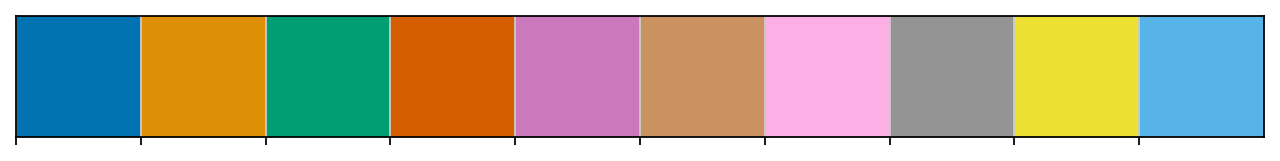

In [20]:
sns.palplot(sns.color_palette("colorblind"))

{'CellState_1': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'CellState_10': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'CellState_2': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), 'CellState_3': (0.8352941176470589, 0.3686274509803922, 0.0), 'CellState_4': (0.8, 0.47058823529411764, 0.7372549019607844), 'CellState_5': (0.792156862745098, 0.5686274509803921, 0.3803921568627451), 'CellState_6': (0.984313725490196, 0.6862745098039216, 0.8941176470588236), 'CellState_7': (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), 'CellState_8': (0.9254901960784314, 0.8823529411764706, 0.2), 'CellState_9': (0.33725490196078434, 0.7058823529411765, 0.9137254901960784), nan: (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)}


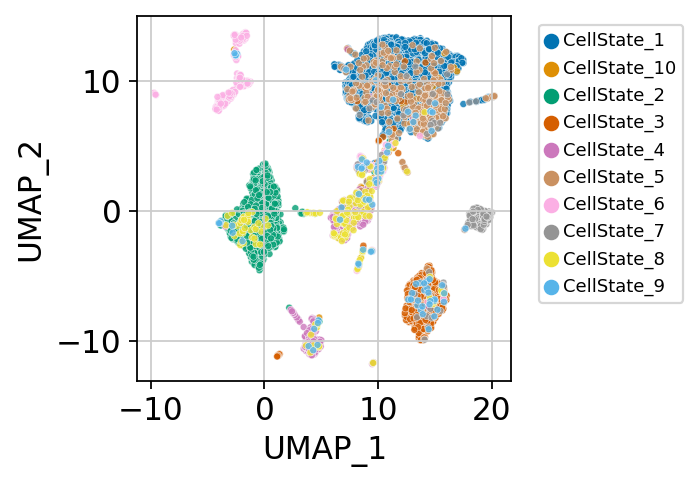

In [21]:
# Sort UMAP_rep by cellassignment
UMAP_rep = UMAP_rep.sort_values(by='cellassignment')

# Create a color mapping for each unique cellassignment
unique_states = UMAP_rep['cellassignment'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

print(color_mapping)

# Plot
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['cellassignment'], palette=color_mapping, alpha=0.8, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

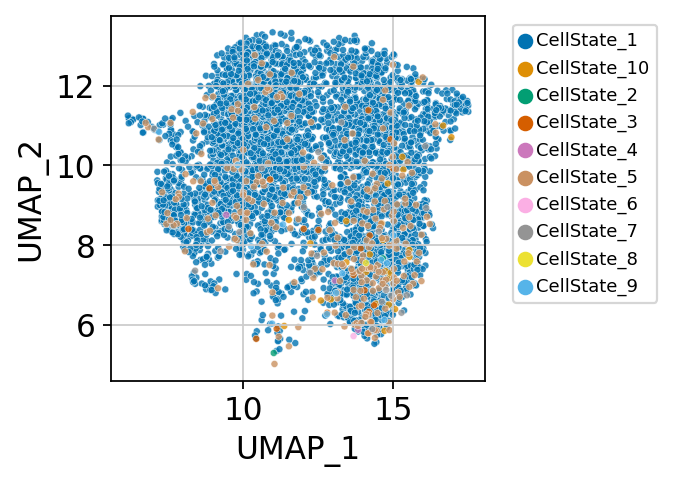

CellState_1     3999
CellState_5      273
CellState_10      26
CellState_7       21
CellState_3       19
CellState_9       12
CellState_4        3
CellState_2        2
CellState_6        1
CellState_8        1
Name: cellassignment, dtype: int64

In [22]:
# 1. Filter the dataframe
filt_dat = UMAP_rep[UMAP_rep['cell_type'] == "microglial_cell"]

# Subset the color mapping to only include the states of interest
subset_color_mapping = {k: color_mapping[k] for k in filt_dat.cellassignment.unique() if k in color_mapping}

# 2. & 3. Plot using hue and the subset color mapping
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_1"], y=filt_dat["UMAP_2"], hue=filt_dat['cellassignment'], palette=subset_color_mapping, alpha=0.8, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

# print how much each cellstate contributes to tehse cells in microglia 
filt_dat.cellassignment.value_counts()

### basically gene expression can't really seperate macrophages 

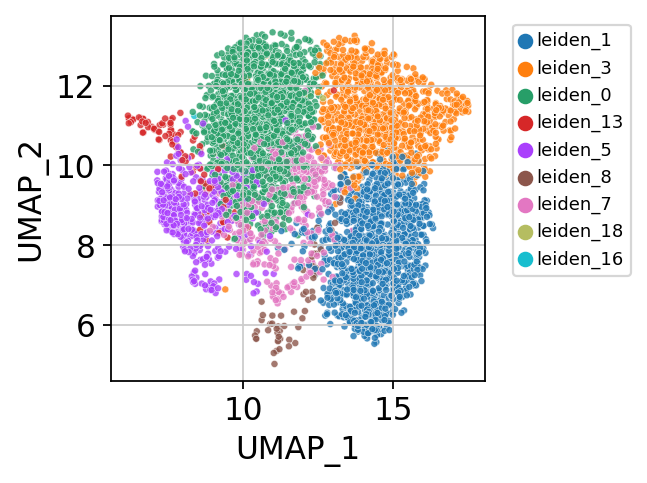

In [23]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_1"], y=filt_dat["UMAP_2"], hue=filt_dat['leiden'], alpha=0.8, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

In [24]:
UMAP_rep[UMAP_rep["cell_type"] == "macrophage"][("cellassignment")].value_counts()

CellState_1    41
CellState_5     9
CellState_7     2
Name: cellassignment, dtype: int64

In [25]:
UMAP_rep[UMAP_rep["cell_type"] == "microglial_cell"][("cellassignment")].value_counts()

CellState_1     3999
CellState_5      273
CellState_10      26
CellState_7       21
CellState_3       19
CellState_9       12
CellState_4        3
CellState_2        2
CellState_6        1
CellState_8        1
Name: cellassignment, dtype: int64

In [26]:
UMAP_rep[UMAP_rep["cell_type"] == "brain_pericyte"][("cellassignment")].value_counts()

CellState_7    138
CellState_5      2
CellState_3      1
CellState_9      1
Name: cellassignment, dtype: int64

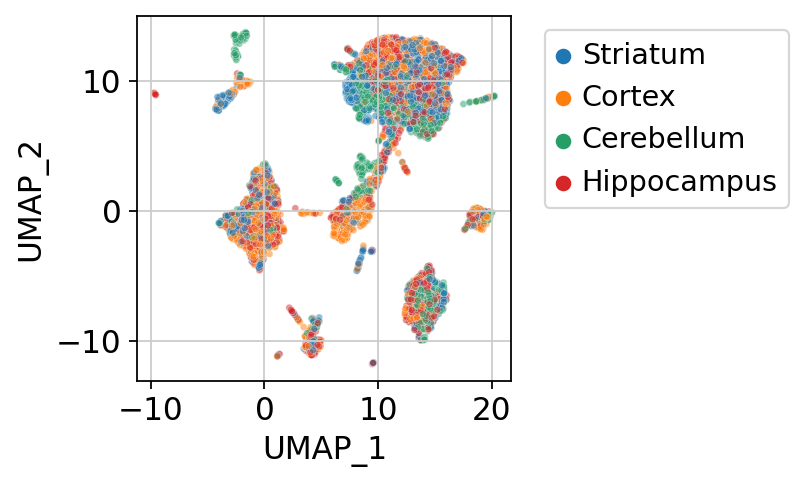

In [27]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['subtissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

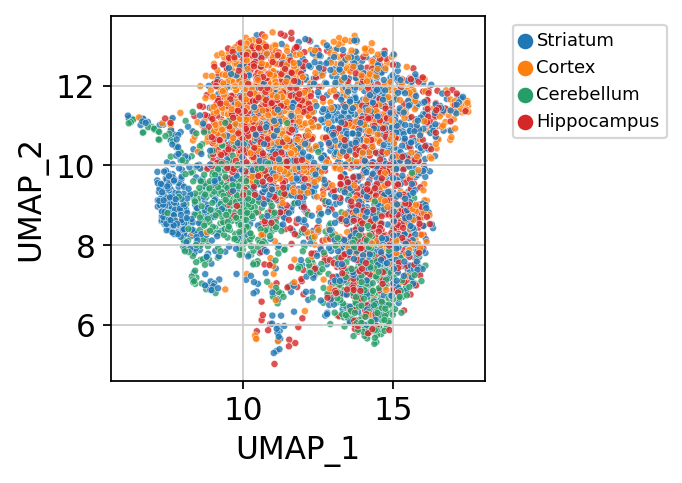

In [33]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_1"], y=filt_dat["UMAP_2"], hue=filt_dat['subtissue'], alpha=0.8, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

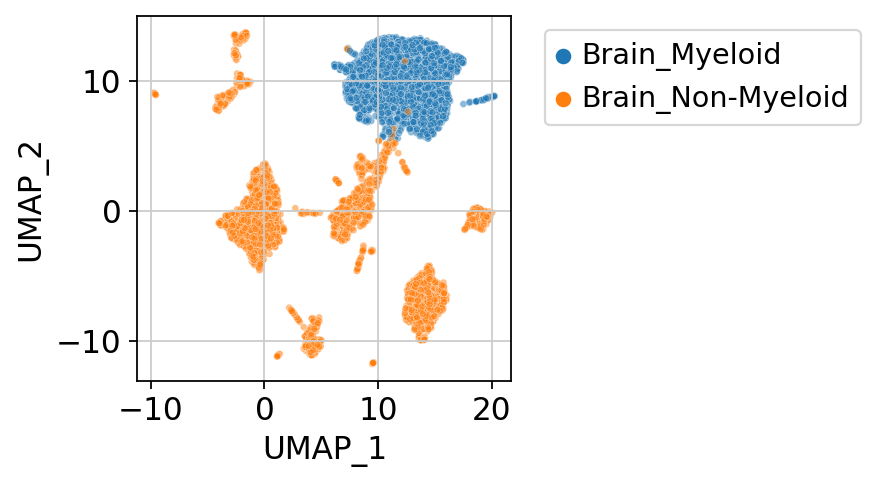

In [28]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['tissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [29]:
UMAP_rep["cellassignment"].value_counts()

CellState_1     4053
CellState_2     1236
CellState_3      649
CellState_4      464
CellState_5      357
CellState_6      251
CellState_7      196
CellState_8      162
CellState_9       87
CellState_10      77
Name: cellassignment, dtype: int64

In [30]:
UMAP_rep[["cellassignment", "mouse.id"]][["mouse.id", "cellassignment"]].value_counts()

mouse.id  cellassignment
3_10_M    CellState_1       934
3_38_F    CellState_1       873
3_39_F    CellState_1       804
3_9_M     CellState_1       621
3_8_M     CellState_1       535
                           ... 
3_11_M    CellState_10        4
3_56_F    CellState_9         2
3_11_M    CellState_1         2
          CellState_5         2
3_8_M     CellState_10        2
Length: 70, dtype: int64

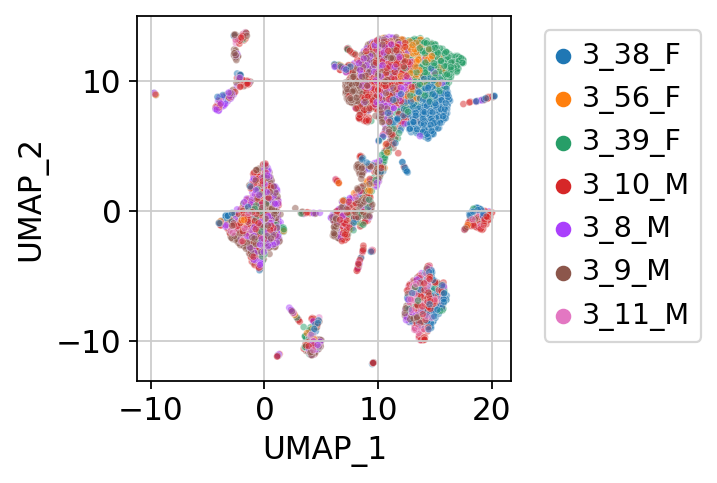

In [31]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['mouse.id'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

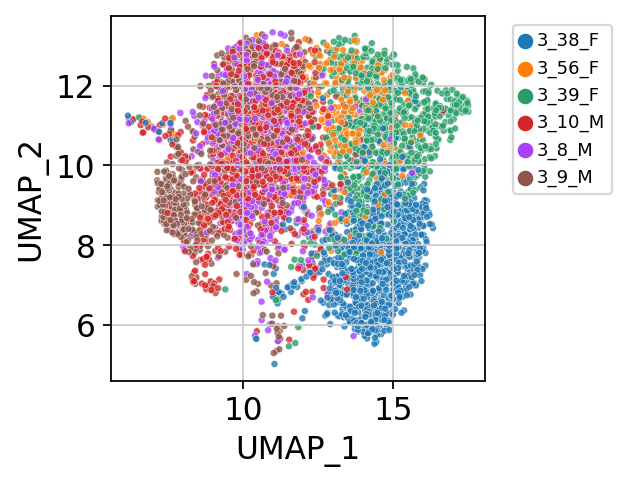

In [34]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_1"], y=filt_dat["UMAP_2"], hue=filt_dat['mouse.id'], alpha=0.8, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

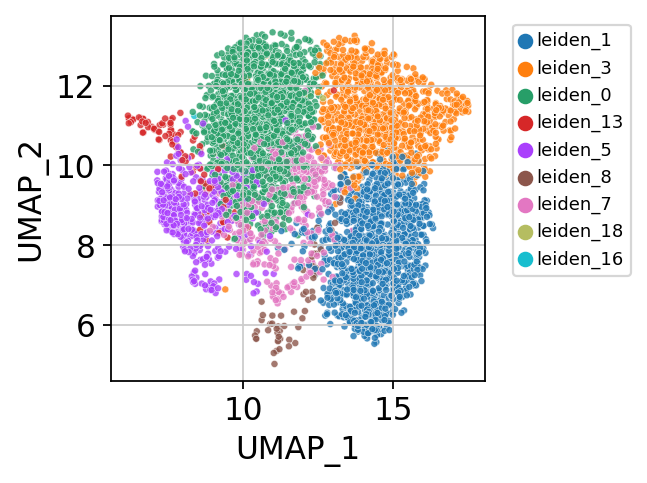

In [35]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_1"], y=filt_dat["UMAP_2"], hue=filt_dat['leiden'], alpha=0.8, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

In [32]:
UMAP_rep

,UMAP_1,UMAP_2,cell_id,leiden,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type,...,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,cell_id_index,548_junc_ratio,549_junc_ratio,psap_expression,cellassignment
3793,14.803660,9.515226,C18-B000825-3_38_F-1-1,leiden_1,microglial cell,NaN,3_38_F,Striatum,Brain_Myeloid,microglial_cell,...,0.0,0.0,0.0,0.0,0.0,3600.0,0.0,1.0,3.151746,CellState_1
4960,14.084992,10.662791,H17-B001176-3_56_F-1-1,leiden_3,microglial cell,NaN,3_56_F,Striatum,Brain_Myeloid,microglial_cell,...,0.0,0.0,0.0,0.0,0.0,4773.0,0.0,1.0,4.184480,CellState_1
4959,14.809203,12.570379,H17-B000826-3_39_F-1-1,leiden_3,microglial cell,NaN,3_39_F,Cortex,Brain_Myeloid,microglial_cell,...,0.0,0.0,0.0,0.0,0.0,4772.0,0.0,1.0,3.711649,CellState_1
4958,15.453991,7.269390,H17-B000825-3_38_F-1-1,leiden_1,microglial cell,NaN,3_38_F,Striatum,Brain_Myeloid,microglial_cell,...,0.0,0.0,0.0,0.0,0.0,4771.0,0.0,1.0,4.494728,CellState_1
4957,10.231897,8.533505,H16-MAA000617-3_10_M-1-1,leiden_0,microglial cell,NaN,3_10_M,Striatum,Brain_Myeloid,microglial_cell,...,0.0,0.0,0.0,0.0,0.0,4770.0,0.0,1.0,3.743329,CellState_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2526,9.148460,1.541635,O11-B000404-3_56_F-1-1,leiden_6,Bergmann glial cell,NaN,3_56_F,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.923875,NaN
2527,7.230542,0.097957,O16-MAA000928-3_9_M-1-1,leiden_6,Bergmann glial cell,NaN,3_9_M,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.669282,NaN
2528,6.552992,2.102588,O18-B000404-3_56_F-1-1,leiden_20,Bergmann glial cell,NaN,3_56_F,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.817566,NaN
2529,9.320457,1.509020,O19-B000404-3_56_F-1-1,leiden_6,Bergmann glial cell,NaN,3_56_F,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.051906,NaN


In [38]:
UMAP_rep.psap_expression.unique()

array([3.1517458, 4.1844797, 3.711649 , ..., 3.817566 , 4.051906 ,
       1.311008 ])

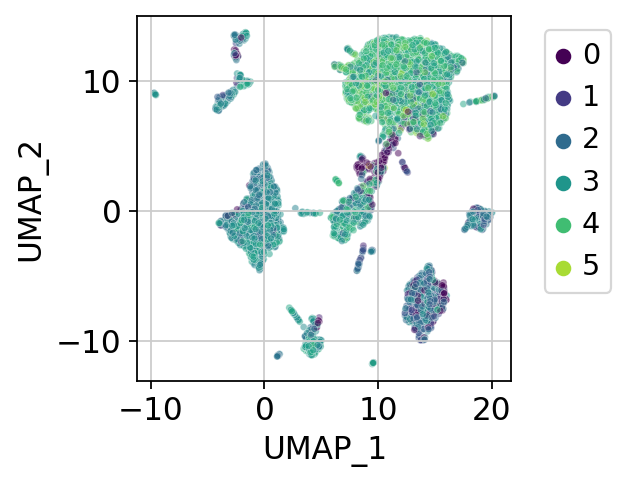

In [49]:
# Make UMAP plot colored by psap_expression color dots with continous color scale
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['psap_expression'], palette='viridis', alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
# add legend to hue map to say normalized gene expression


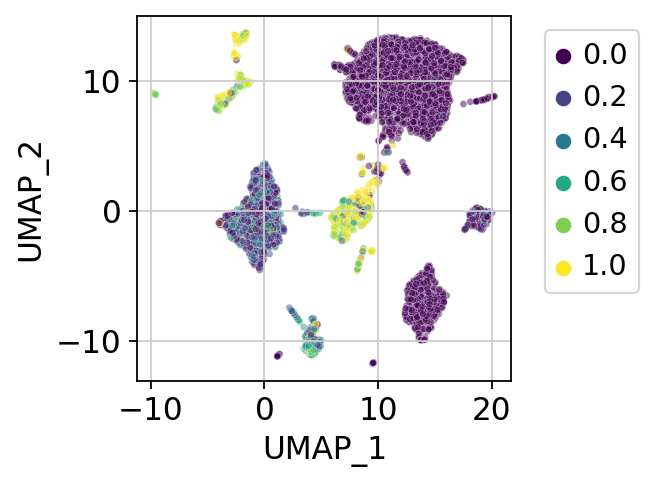

In [50]:
# Make UMAP plot colored by 548_junc_ratio 
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['548_junc_ratio'], palette='viridis', alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


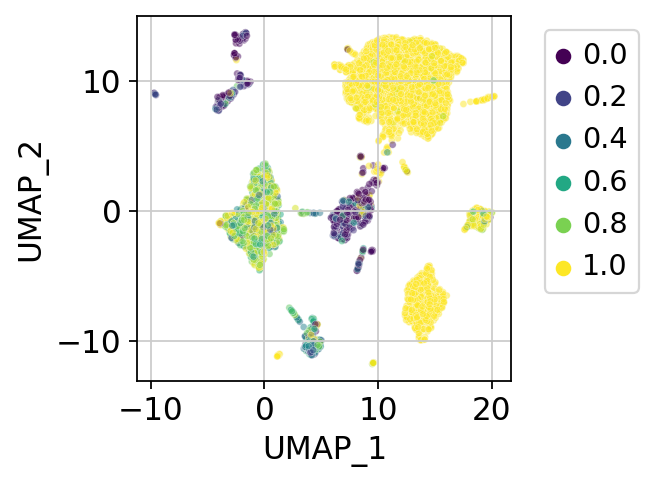

In [51]:
# Make UMAP plot colored by 549_junc_ratio 
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_1"], y=UMAP_rep["UMAP_2"], hue=UMAP_rep['549_junc_ratio'], palette='viridis', alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
